In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Layer
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import drive
drive.mount('/content/drive')

# Set seeds for reproducibility
np.random.seed(1234)
tf.random.set_seed(1234)

Mounted at /content/drive


<>:86: SyntaxWarning: invalid escape sequence '\s'
<>:87: SyntaxWarning: invalid escape sequence '\s'
<>:88: SyntaxWarning: invalid escape sequence '\s'
<>:86: SyntaxWarning: invalid escape sequence '\s'
<>:87: SyntaxWarning: invalid escape sequence '\s'
<>:88: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_10210/2682779015.py:86: SyntaxWarning: invalid escape sequence '\s'
  data_train = pd.read_csv(base_path + 'train_FD001.txt', sep="\s+", header=None)
/tmp/ipykernel_10210/2682779015.py:87: SyntaxWarning: invalid escape sequence '\s'
  data_test = pd.read_csv(base_path + 'test_FD001.txt', sep="\s+", header=None)
/tmp/ipykernel_10210/2682779015.py:88: SyntaxWarning: invalid escape sequence '\s'
  actual_rul = pd.read_csv(base_path + 'RUL_FD001.txt', sep="\s+", header=None)
/tmp/ipykernel_10210/2682779015.py:10: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in


--- LRU Model Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ linear_recurrent_unit_1         │ (None, 15)             │         1,245 │
│ (LinearRecurrentUnit)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331 (5.20 KB)

 Trainable params: 1,331 (5.20 KB)

 Non-trainable params: 0 (0.00 B)


Training Linear Recurrent Unit (LRU)...
Epoch 1/100


248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 4316.7456 - mae: 62.1443 - val_loss: 1792.2113 - val_mae: 44.6298
Epoch 2/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1476.1278 - mae: 32.3683 - val_loss: 686.4845 - val_mae: 24.8455
Epoch 3/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 701.1256 - mae: 20.5325 - val_loss: 615.7601 - val_mae: 22.9275
Epoch 4/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 627.7501 - mae: 19.1536 - val_loss: 581.1979 - val_mae: 22.5274
Epoch 5/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 586.5648 - mae: 18.4919 - val_loss: 556.0749 - val_mae: 22.2246
Epoch 6/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 555.6067 - mae: 18.0081 - val_loss: 534.0229 - val_mae: 21.8288
Epoch 7/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 527.6008 - mae: 17.5319 - val_loss: 502.8187 - val_mae: 21.8824
Epoch 8/100
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 496.5008 - mae: 16.9754 - val_loss: 475.8802 - val_mae: 20.6870
Epoc

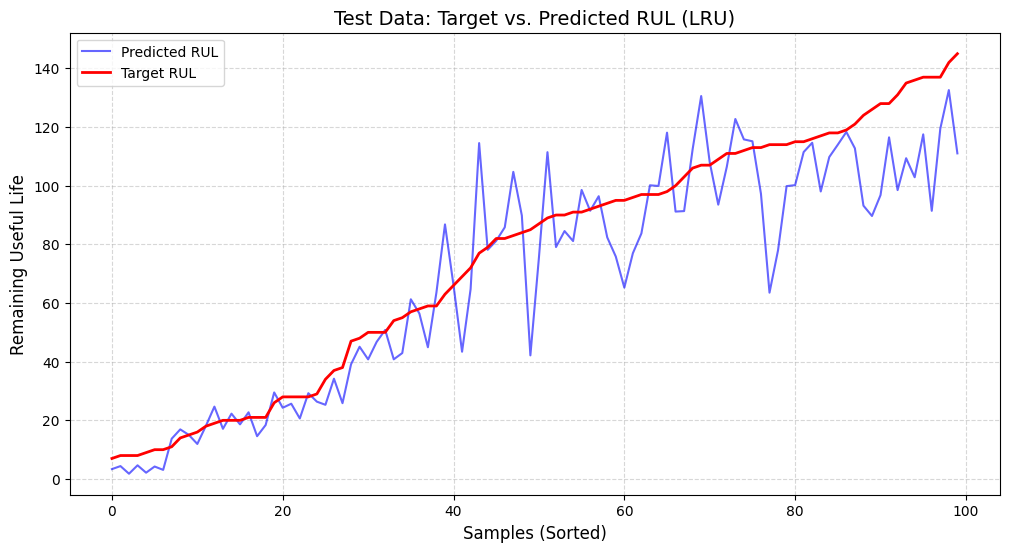

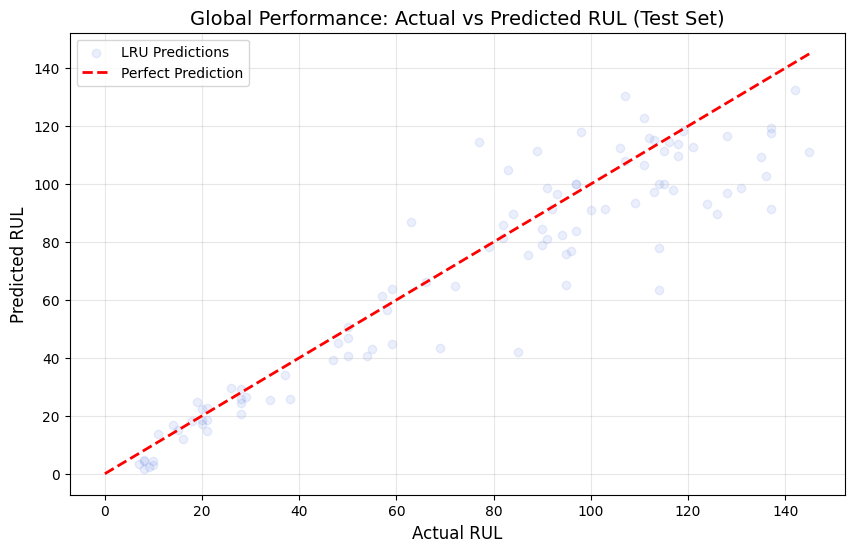

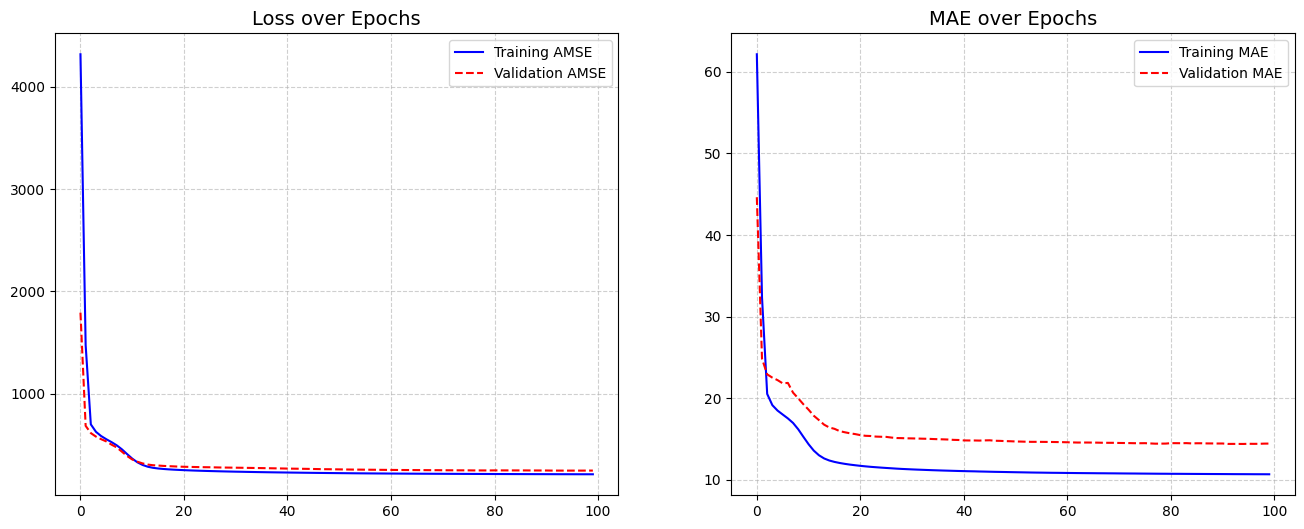

In [5]:
# ---------------------------------------------------------
# 1. Custom DeepMind Linear Recurrent Unit (LRU) Layer
# ---------------------------------------------------------
class LinearRecurrentUnit(Layer):
    """
    TensorFlow implementation of the Linear Recurrent Unit (LRU)
    based on the DeepMind paper: "Resurrecting Recurrent Neural Networks for Long Sequences".
    """
    def __init__(self, state_dim, output_dim, r_min=0.9, r_max=0.999, max_phase=6.28, **kwargs):
        super(LinearRecurrentUnit, self).__init__(**kwargs)
        self.state_dim = state_dim
        self.output_dim = output_dim
        self.r_min = r_min
        self.r_max = r_max
        self.max_phase = max_phase

    def build(self, input_shape):
        H = int(input_shape[-1])
        N = self.state_dim

        # Uniform sampling for stable initialization bounds
        u1 = tf.random.uniform((N,), minval=1e-5, maxval=1.0)
        u2 = tf.random.uniform((N,), minval=1e-5, maxval=1.0)

        # Exponential parameterization initialization
        nu_log_init = tf.math.log(-0.5 * tf.math.log(u1 * (self.r_max**2 - self.r_min**2) + self.r_min**2))
        theta_log_init = tf.math.log(self.max_phase * u2)

        self.nu_log = self.add_weight(shape=(N,), initializer=tf.keras.initializers.Constant(nu_log_init), trainable=True, name='nu_log')
        self.theta_log = self.add_weight(shape=(N,), initializer=tf.keras.initializers.Constant(theta_log_init), trainable=True, name='theta_log')

        # Complex weights mapped to real/imaginary components for Adam optimization
        self.B_re = self.add_weight(shape=(N, H), initializer=tf.keras.initializers.RandomNormal(stddev=1.0/tf.math.sqrt(2.0*H)), trainable=True, name='B_re')
        self.B_im = self.add_weight(shape=(N, H), initializer=tf.keras.initializers.RandomNormal(stddev=1.0/tf.math.sqrt(2.0*H)), trainable=True, name='B_im')

        self.C_re = self.add_weight(shape=(self.output_dim, N), initializer=tf.keras.initializers.RandomNormal(stddev=1.0/tf.math.sqrt(float(N))), trainable=True, name='C_re')
        self.C_im = self.add_weight(shape=(self.output_dim, N), initializer=tf.keras.initializers.RandomNormal(stddev=1.0/tf.math.sqrt(float(N))), trainable=True, name='C_im')

        self.D = self.add_weight(shape=(self.output_dim, H), initializer=tf.keras.initializers.RandomNormal(), trainable=True, name='D')

        super(LinearRecurrentUnit, self).build(input_shape)

    def call(self, inputs):
        # inputs shape: (batch, seq_len, features)

        # 1. Reconstruct Complex Lambda
        mag = tf.exp(-tf.exp(self.nu_log))
        phase = tf.exp(self.theta_log)
        Lambda = tf.complex(mag * tf.math.cos(phase), mag * tf.math.sin(phase))

        # 2. Forward-Pass Normalization (gamma_log)
        gamma_log = tf.math.log(tf.math.sqrt(1.0 - tf.math.square(tf.math.abs(Lambda)) + 1e-7))

        B = tf.complex(self.B_re, self.B_im)
        B_norm = B * tf.cast(tf.expand_dims(tf.exp(gamma_log), axis=-1), tf.complex64)
        C = tf.complex(self.C_re, self.C_im)

        # 3. Recurrence Step Function
        def step(x_prev, u_k):
            u_k_c = tf.cast(u_k, tf.complex64)
            # Matrix multiplication: u_k_c @ B_norm.T
            bu = tf.matmul(u_k_c, B_norm, transpose_b=True)
            return Lambda * x_prev + bu

        batch_size = tf.shape(inputs)[0]
        initial_state = tf.zeros((batch_size, self.state_dim), dtype=tf.complex64)

        # Transpose inputs to iterate over time: (seq_len, batch, features)
        inputs_t = tf.transpose(inputs, [1, 0, 2])
        x_seq = tf.scan(step, inputs_t, initializer=initial_state)

        # 4. Extract Final State and Compute Output
        x_last = x_seq[-1]
        u_last = inputs_t[-1]

        # y_last = Re(C @ x_last) + (D @ u_last)
        cx = tf.matmul(x_last, C, transpose_b=True)
        y_last = tf.math.real(cx) + tf.matmul(u_last, self.D, transpose_b=True)

        return y_last

# ---------------------------------------------------------
# 2. Data Loading & Preprocessing
# ---------------------------------------------------------
base_path = '/content/drive/MyDrive/Amath 445 Project/'
data_train = pd.read_csv(base_path + 'train_FD001.txt', sep="\s+", header=None)
data_test = pd.read_csv(base_path + 'test_FD001.txt', sep="\s+", header=None)
actual_rul = pd.read_csv(base_path + 'RUL_FD001.txt', sep="\s+", header=None)

columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32']

data_train = data_train.iloc[:, :26]
data_test = data_test.iloc[:, :26]
data_train.columns = columns
data_test.columns = columns

constant_columns = ['TRA','T2','P2','epr','farB','Nf_dmd','PCNfR_dmd']
data_train.drop(columns=constant_columns, inplace=True)
data_test.drop(columns=constant_columns, inplace=True)

# Data Smoothing (Exponential Moving Average)
features_to_process = data_train.columns.difference(['unit_number', 'time_in_cycles'])
data_train[features_to_process] = data_train.groupby('unit_number')[features_to_process].transform(lambda x: x.ewm(span=10, adjust=False).mean())
data_test[features_to_process] = data_test.groupby('unit_number')[features_to_process].transform(lambda x: x.ewm(span=10, adjust=False).mean())

# Piecewise Linear RUL Target Generation
def add_piecewise_RUL(df, upper_bound=130):
    rul_data = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    rul_data.columns = ['unit_number', 'max_cycles']
    df = df.merge(rul_data, on=['unit_number'], how='left')
    df['RUL'] = df['max_cycles'] - df['time_in_cycles']
    df['RUL'] = df['RUL'].clip(upper=upper_bound)
    df.drop(columns=['max_cycles'], inplace=True)
    return df

data_train = add_piecewise_RUL(data_train, upper_bound=130)

# Feature Scaling
scaler = MinMaxScaler()
data_train[features_to_process] = scaler.fit_transform(data_train[features_to_process])
data_test[features_to_process] = scaler.transform(data_test[features_to_process])

# Sequence Generation
sequence_length = 30
sequence_cols = features_to_process.tolist()

def generate_sequences(df, seq_length, seq_cols):
    data_array = df[seq_cols].values
    num_elements = data_array.shape[0]
    for start, stop in zip(range(0, num_elements - seq_length), range(seq_length, num_elements)):
        yield data_array[start:stop, :]

def generate_labels(df, seq_length, label_col):
    data_array = df[label_col].values
    num_elements = data_array.shape[0]
    return data_array[seq_length:num_elements]

x_train, y_train = [], []
for unit in data_train['unit_number'].unique():
    unit_data = data_train[data_train['unit_number'] == unit]
    if len(unit_data) >= sequence_length:
        x_train.extend(list(generate_sequences(unit_data, sequence_length, sequence_cols)))
        y_train.extend(list(generate_labels(unit_data, sequence_length, ['RUL'])))

x_train = np.array(x_train)
y_train = np.array(y_train).reshape(-1)

# Generate Sample Weights: De-prioritize the early-life flatline region (RUL = 130)
sample_weights = np.where(y_train == 130, 0.1, 1.0)

# Extract Test Sequences (Last sequence only)
x_test = []
for unit in data_test['unit_number'].unique():
    unit_data = data_test[data_test['unit_number'] == unit]
    data_array = unit_data[sequence_cols].values
    if len(unit_data) >= sequence_length:
        x_test.append(data_array[-sequence_length:, :])
    else:
        pad_size = sequence_length - len(unit_data)
        x_test.append(np.pad(data_array, ((pad_size, 0), (0, 0)), mode='edge'))

x_test = np.array(x_test)
y_test = actual_rul.iloc[:, 0].values.reshape(-1)

# ---------------------------------------------------------
# 3. Model Architecture & Custom Loss (AMSE)
# ---------------------------------------------------------
def asymmetric_mse(penalty_factor=3.0):
    def loss(y_true, y_pred):
        y_true, y_pred = tf.cast(y_true, tf.float32), tf.cast(y_pred, tf.float32)
        error = y_true - y_pred
        squared_error = tf.square(error)
        return tf.reduce_mean(tf.where(error < 0, penalty_factor * squared_error, squared_error))
    return loss

model_lru = Sequential()
# The custom LRU Layer handles the temporal state natively
model_lru.add(LinearRecurrentUnit(state_dim=15, output_dim=15, input_shape=(x_train.shape[1], x_train.shape[2])))
model_lru.add(Dense(units=5, activation='relu'))
model_lru.add(Dense(units=1, activation='linear'))

model_lru.compile(loss=asymmetric_mse(penalty_factor=3.0), optimizer='adam', metrics=['mae'])
print("\n--- LRU Model Summary ---")
model_lru.summary()

# ---------------------------------------------------------
# 4. Training with Early Stopping
# ---------------------------------------------------------
early_stopper = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("\nTraining Linear Recurrent Unit (LRU)...")
history_lru = model_lru.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    sample_weight=sample_weights,
    callbacks=[early_stopper],
    verbose=1
)

# ---------------------------------------------------------
# 5. Evaluation & Plotting
# ---------------------------------------------------------
y_train_pred_lru = model_lru.predict(x_train).reshape(-1)
y_test_pred_lru = model_lru.predict(x_test).reshape(-1)

def get_comprehensive_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    over_count = np.sum(y_pred > y_true)
    over_pct = (over_count / len(y_true)) * 100
    return mse, mae, r2, over_count, over_pct

metrics_lru = get_comprehensive_metrics(y_test, y_test_pred_lru)

comparison_df = pd.DataFrame({
    'Architecture': ['LRU (AMSE + ES)'],
    'Test MSE': [round(metrics_lru[0], 4)],
    'Test MAE': [round(metrics_lru[1], 4)],
    'Test R2 Score': [round(metrics_lru[2], 4)],
    'Over-estimates (#)': [int(metrics_lru[3])],
    'Over-estimates (%)': [f"{metrics_lru[4]:.2f}%"]
})
print("\n--- LRU Performance ---")
print(comparison_df.to_markdown(index=False))

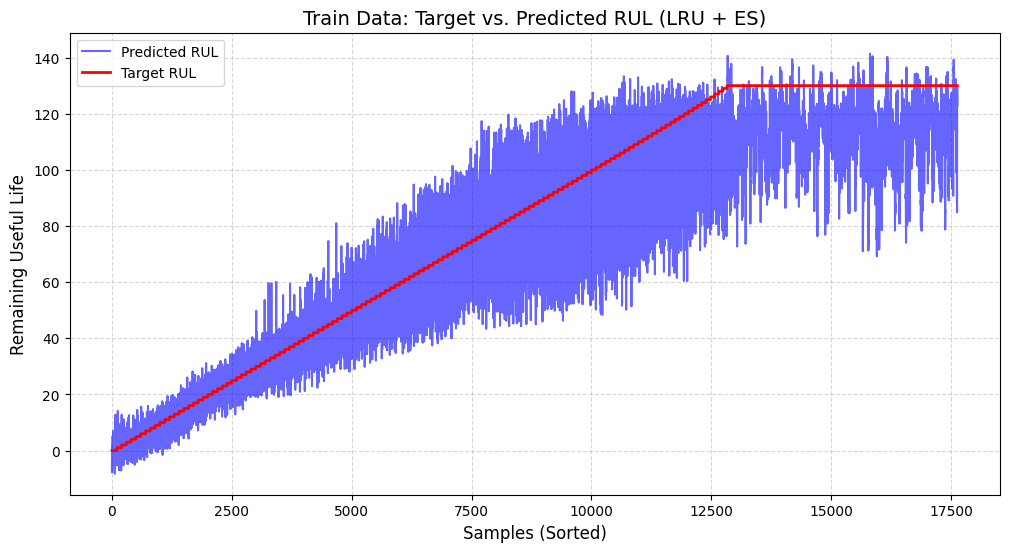

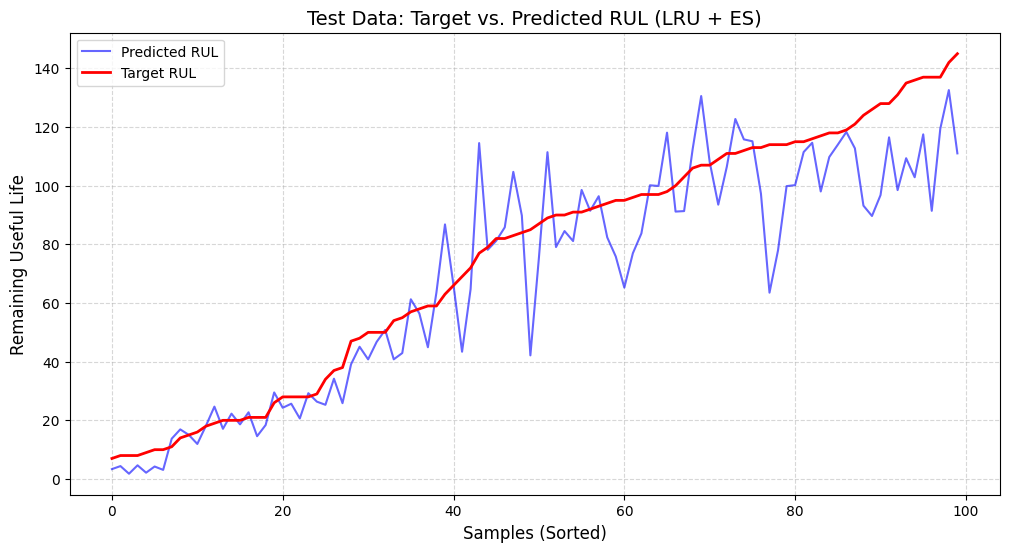

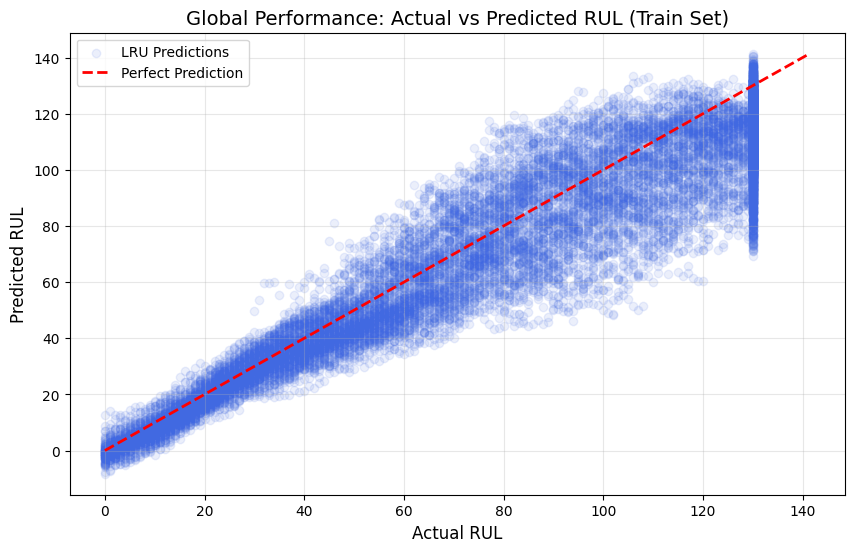

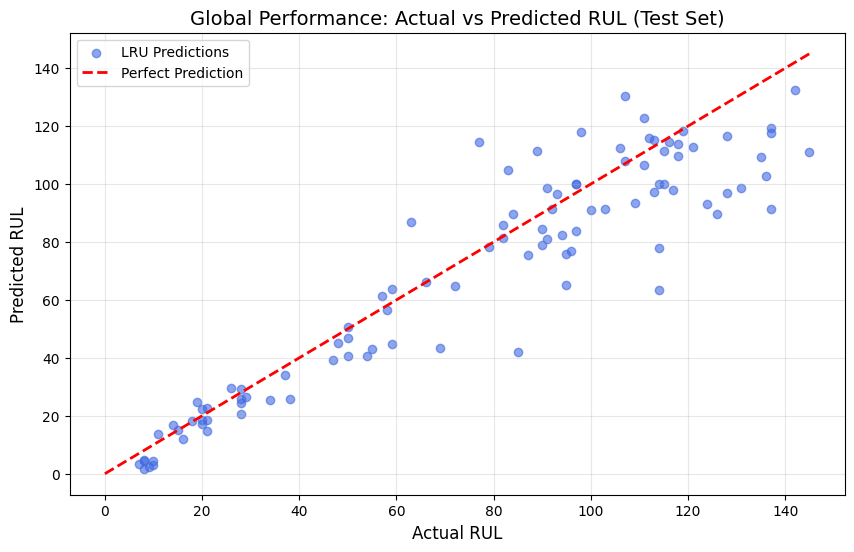

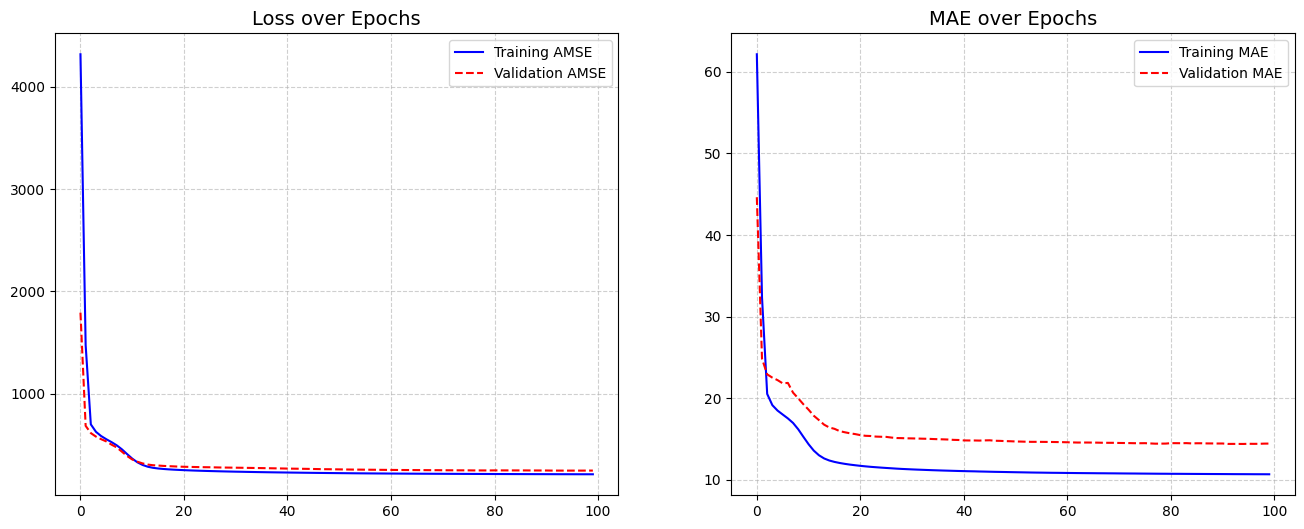

In [8]:
# --- Plotting Functions ---
def plot_sorted_rul(y_true, y_pred, title):
    sort_indices = np.argsort(y_true)
    plt.figure(figsize=(12, 6))
    plt.plot(y_pred[sort_indices], color='blue', alpha=0.6, label='Predicted RUL')
    plt.plot(y_true[sort_indices], color='red', linewidth=2, label='Target RUL')
    plt.title(title, fontsize=14)
    plt.xlabel('Samples (Sorted)', fontsize=12)
    plt.ylabel('Remaining Useful Life', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def plot_actual_vs_predicted(y_true, y_pred, title, alpha):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=alpha, color='royalblue', label='LRU Predictions')
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
    plt.title(title, fontsize=14)
    plt.xlabel('Actual RUL', fontsize=12)
    plt.ylabel('Predicted RUL', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_learning_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.plot(history.history['loss'], 'b-', label='Training AMSE')
    ax1.plot(history.history['val_loss'], 'r--', label='Validation AMSE')
    ax1.set_title('Loss over Epochs', fontsize=14)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(history.history['mae'], 'b-', label='Training MAE')
    ax2.plot(history.history['val_mae'], 'r--', label='Validation MAE')
    ax2.set_title('MAE over Epochs', fontsize=14)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_sorted_rul(y_train, y_train_pred_lru, 'Train Data: Target vs. Predicted RUL (LRU + ES)')
plot_sorted_rul(y_test, y_test_pred_lru, 'Test Data: Target vs. Predicted RUL (LRU + ES)')
plot_actual_vs_predicted(y_train, y_train_pred_lru, 'Global Performance: Actual vs Predicted RUL (Train Set)', 0.1)
plot_actual_vs_predicted(y_test, y_test_pred_lru, 'Global Performance: Actual vs Predicted RUL (Test Set)', 0.6)
plot_learning_curves(history_lru)